I have note been able to find the code that Dale and Bex worked on to generate the 'new' set of tassel cap coefficients that were intended to replace the currently implemented ones (from Crist 1985). Instead, I am drafting a notebook/ pythons cript here that will create a set of tassel cap coefficients.

The reason I am doing this is beacuse:
 * while the processing of our ARD should mean that there are no differences between the Landsat sensors, there are still likely to be some differences.
 * If we want to do tassel cap indices on Sentinel-2 data, we will need a set of Sentinel-2 coefficients. While these exist in the literature, similar to issues noted with Landsat coefficients in the literature, they are not tailored to our ARD data, and may also be generated on data at differing processing stages (e.g. you can't use coefficients made from top-of-atmosphere data on bottom-of-atmosphere refelctance).
 * I'm not comfortable with us having code that uses hard-coded coefficients, but without the code that shows how we got to those coefficients. If we want to implement new coefficients that are built on our ARD, we need to document how they were generated. While there's the  Statistics paper by Bex, Dale and Norman that explains how those coefficients were made, the code has become lost it seems.

Steps to generating tassel cap coefficients
 * I will follow the above mentioned paper as much as possible.
 * Use annnual geomedians made from DEA ARD
 * calibrate the TCT (tassel cap transformation) on continental landsat-8 product
 * The paper chose to calibrate on a single sensor, which I will do as well to begin with, but I believe we shoudl calibrate for each Landsat sensor, as well as Sentinel-2
 * Generate over a tile where we have wetlands that we can then use to compare impacts of TCT on downstream products

In [52]:
%pip uninstall dea-tools -y
%pip install dea-tools==0.4.4 -q


Found existing installation: dea-tools 0.4.4
Uninstalling dea-tools-0.4.4:
  Successfully uninstalled dea-tools-0.4.4
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Imports

In [ ]:
import datacube
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from sklearn.decomposition import PCA
from scipy.linalg import orthogonal_procrustes

from dea_tools.datahandling import load_ard
from dea_tools.dask import create_local_dask_cluster
from dea_tools.plotting import display_map, rgb
from dea_tools.classification import sklearn_flatten, sklearn_unflatten


In [ ]:
client = create_local_dask_cluster(return_client=True)


/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38747 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/38747/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/38747/status,Workers: 1
Total threads: 2,Total memory: 14.25 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43737,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/38747/status,Total threads: 2
Started: Just now,Total memory: 14.25 GiB
Comm: tcp://127.0.0.1:42389,Total threads: 2
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/41579/status,Memory: 14.25 GiB
Nanny: tcp://127.0.0.1:33115,


In [ ]:
dc = datacube.Datacube(app="tct_test")


### Datacube query

We'll build the first pass of the TCT on yearly geomedian data for Landsat 8/9.

For now I will work with the landsat 8/9 geomedians, but eventually should do this for each sensor/ geomedian

In [ ]:
# Coordinates for Broome, Western Australia
lat = -18.10
lon = 122.32
lat_buffer = 0.18
lon_buffer = 0.18

# Combine central coordinates with buffer values to create the latitude and longitude range for the analysis
lat_range = (lat - lat_buffer, lat + lat_buffer)
lon_range = (lon - lon_buffer, lon + lon_buffer)

# Set the range of dates for the analysis
time_range = "2024"


In [ ]:
query = {
    "y": lat_range,
    "x": lon_range,
    "time": time_range,
    "dask_chunks": {"x": 1000, "y": 1000},
}


In [ ]:
gm = dc.load(
    product="ga_ls8cls9c_gm_cyear_3",
    measurements=[
        "nbart_red",
        "nbart_green",
        "nbart_blue",
        "nbart_nir",
        "nbart_swir_1",
        "nbart_swir_2",
    ],
    resolution=(-30, 30),
    output_crs="EPSG:3577",
    **query,
)


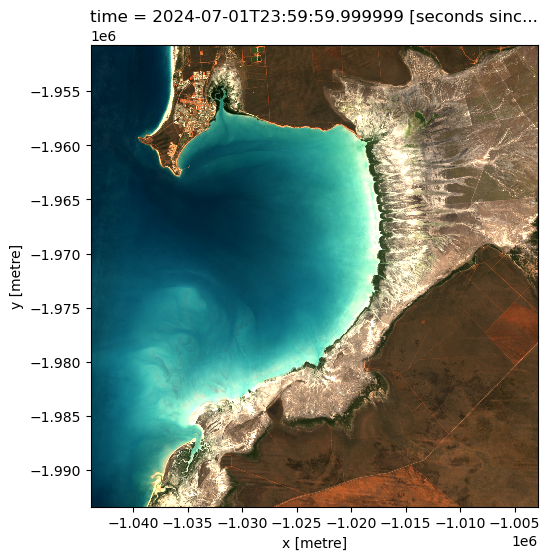

In [ ]:
rgb(gm, bands=["nbart_red", "nbart_green", "nbart_blue"], size=6, robust=True)


### Reshape the geomedian data so it can be used in a PCA, then do PCA


In [ ]:
# reshape data for PCA
flat_data = sklearn_flatten(gm)


In [ ]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(flat_data)
components = pca.components_


In [ ]:
components


array([[ 0.21546988,  0.02337799, -0.04278248,  0.50606252,  0.68068534,
         0.48141879],
       [ 0.48255717,  0.63891745,  0.55428619,  0.12329874, -0.17020747,
        -0.08669904],
       [ 0.05968066, -0.12764402, -0.22408653,  0.76328995, -0.20538647,
        -0.55239053]])

### Procrustes rotation

### conceptual TCT axes

Apparently you need a set of 'target' TCT axes to align the new TCT to. Given these are landsat 8, I'm going to align them to landsat 5 aka the Crist 1985 coefficients.

I don't fully understand this step yet and need to do some research on it. How are these target TCT axes decided, and how do I know if I've chosen the right ones? 

Also apparently, these targets don't need to be perfect as they're "conceptual guides" to help rotate the PCA components to physically meaningful space.

They can be refined by sampling land cover (veg, water, soil etc), computing the mean relfectance across bands for each cover type, normalising each vector to a unit length.

In [ ]:
def normalize(v):
    return v / np.linalg.norm(v)


In [ ]:
# target axes based on existing landsat
TCT_ideal = np.array(
    [
        normalize([0.3029, 0.2786, 0.4733, 0.5599, 0.5080, 0.1872]),
        normalize([-0.2941, -0.2430, -0.5424, 0.7276, 0.0713, -0.1608]),
        normalize([0.1511, 0.1973, 0.3283, 0.3407, -0.7117, -0.4559]),
    ]
)


In [ ]:
components_centered = components - components.mean(axis=0)
TCT_ideal_centered = TCT_ideal - TCT_ideal.mean(axis=0)


In [ ]:
# solve procrustes

Q, _ = orthogonal_procrustes(components_centered, TCT_ideal_centered)


In [ ]:
new_tct_coeffs = components @ Q


### Show new coefficients, compare to current ones

WARNING: These TC coefficients are hot garbage and mean nothing, they are just here for now to demonstrate the workflow. Without proper calibration they are NOT meaningful and should NOT be used.

In [ ]:
tct_labels = ["brightness", "greenness", "wetness"]
bands = [
    "nbart_red",
    "nbart_green",
    "nbart_blue",
    "nbart_nir",
    "nbart_swir_1",
    "nbart_swir_2",
]

for i, label in enumerate(tct_labels):
    coeffs = new_tct_coeffs[i]
    print(f"TCT {label.capitalize()} coefficients:")
    for band, value in zip(bands, coeffs):
        print(f"  {band}: {value:.4f}")


TCT Brightness coefficients:
  nbart_red: 0.5006
  nbart_green: -0.0856
  nbart_blue: 0.3416
  nbart_nir: 0.0016
  nbart_swir_1: 0.3479
  nbart_swir_2: 0.7101
TCT Greenness coefficients:
  nbart_red: -0.0964
  nbart_green: -0.6072
  nbart_blue: -0.6741
  nbart_nir: 0.1693
  nbart_swir_1: -0.0888
  nbart_swir_2: 0.3622
TCT Wetness coefficients:
  nbart_red: 0.3488
  nbart_green: -0.1669
  nbart_blue: 0.1966
  nbart_nir: -0.2176
  nbart_swir_1: -0.8718
  nbart_swir_2: 0.0670
